# HW_L03_03_ML

## 1. Initial Plan and Preprocessing

In this exercise, you will use the Scikit-Learn library to build a complete machine learning pipeline. You will go beyond simple data analysis and build predictive models. The main focus is on data splitting, feature engineering, model selection, and hyperparameter tuning. In this exercise, you will use a synthetic dataset (`delivery_data.csv`) that simulates data from a shipping company, and you must train two machine learning models:

1. Regression model: To accurately estimate delivery time in minutes for display to the customer.
2. Classification model: To predict whether an order will be delivered with a delay (more than 45 minutes) or not (to send a discount code or a proactive apology).


In [54]:
# basic
import os

# Analysis
import numpy as np
import pandas as pd

# plot
import matplotlib.pyplot as plt
import matplotlib.patches as patches # Design plot
import seaborn as sns

## 1. Regression model

## Part 1
Before training the model, we must prepare the data. For this purpose, the following steps must be followed:

1. Loading and Splitting:
   - Load the dataset.
   - Define the feature matrix (X) and the target vector (y). (Currently, use the `Delivery_Time_min` column for the target.)
   - Using `train_test_split`, split the data into training (80%) and testing (20%) sets. Be sure to use `random_state` so that results are reproducible.

2. Building the Transformation Pipeline

- We have two types of features: numerical features (`Distance_km`, etc.) and categorical features (`Traffic_Level`, `Weather`).
- Build a `ColumnTransformer` that performs the following operations:
  - For numerical columns: fill missing values with the mean (`SimpleImputer`) and then standardize the data (`StandardScaler`).
  - For categorical columns: fill missing values with the most frequent value (`most_frequent`) and then convert text into vectors (`OneHotEncoder`).
- Note: Linear models require the data to be scaled and cannot process string values directly.



In [56]:
# Read data
delivery_time_min = pd.read_csv("delivery_data.csv")

In [57]:
delivery_time_min.columns

Index(['Distance_km', 'Prep_Time_min', 'Courier_Experience_yrs', 'Weather',
       'Traffic_Level', 'Vehicle_Type', 'Delivery_Time_min', 'Is_Late'],
      dtype='str')

In [58]:
delivery_time_min.head()

,Distance_km,Prep_Time_min,Courier_Experience_yrs,Weather,Traffic_Level,Vehicle_Type,Delivery_Time_min,Is_Late
0,5.993428,11.624109,7,NaN,High,Scooter,44.013542,0
1,4.723471,14.277407,2,Sunny,High,Car,35.527712,0
2,6.295377,11.037900,9,Rainy,High,Scooter,48.567934,1
3,8.046060,13.460192,7,Sunny,High,Car,50.452710,1
4,4.531693,5.531927,7,Rainy,Medium,Bicycle,47.632817,1


In [59]:
delivery_time_min.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             2000 non-null   float64
 1   Prep_Time_min           1895 non-null   float64
 2   Courier_Experience_yrs  2000 non-null   int64  
 3   Weather                 1893 non-null   str    
 4   Traffic_Level           2000 non-null   str    
 5   Vehicle_Type            2000 non-null   str    
 6   Delivery_Time_min       2000 non-null   float64
 7   Is_Late                 2000 non-null   int64  
dtypes: float64(3), int64(2), str(3)
memory usage: 125.1 KB


In [60]:
delivery_time_min.describe()

,Distance_km,Prep_Time_min,Courier_Experience_yrs,Delivery_Time_min,Is_Late
count,2000.000000,1895.000000,2000.000000,2000.000000,2000.000000
mean,5.097968,15.031132,4.552500,53.317833,0.549000
std,1.956540,4.942245,2.885898,27.200221,0.497718
min,0.500000,5.000000,0.000000,10.000000,0.000000
25%,3.754676,11.453845,2.000000,33.683481,0.000000
50%,5.089383,15.033999,5.000000,47.682737,1.000000
75%,6.365955,18.350682,7.000000,67.152951,1.000000
max,12.705463,34.631189,9.000000,183.617375,1.000000


In [61]:
delivery_time_min.isnull().sum()

Distance_km                 0
Prep_Time_min             105
Courier_Experience_yrs      0
Weather                   107
Traffic_Level               0
Vehicle_Type                0
Delivery_Time_min           0
Is_Late                     0
dtype: int64

The two columns `Prep_Time_min` and `Weather` contain NaN values, so we fill them with the mean (`SimpleImputer`) and then standardize the data (`StandardScaler`).


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


# drop Is_Late columns 
data_frame_delivery = delivery_time_min.drop(columns=["Is_Late"]).copy()

# 1st part: create x and y
# label columns or target
target = "Delivery_Time_min"

# create X and y
# X: model learn - X is matrix so X is Capital character
X = data_frame_delivery.drop(columns=[target])
# y: Answer or label - y is vector and Small character
y = data_frame_delivery[target]


# 2nd part: train_test_split
# user train_test_split for creat train data and test data
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 1)

# 3rd part: ColumnTransformer
# numeric columns and categorical columns
numerical_columns = ["Distance_km", "Prep_Time_min", "Courier_Experience_yrs"]
categorical_columns = ["Weather", "Traffic_Level", "Vehicle_Type"] # this is str

# pipeline for numerical columns
numerical_transformer = Pipeline([("imputer", SimpleImputer(strategy="mean")),
                                  ("scaler", StandardScaler())])

# pipeline for categorical columns
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("one_hot", OneHotEncoder(handle_unknown="ignore"))])


preprocessor = ColumnTransformer(
    transformers=[("num", numerical_transformer, numerical_columns),
                  ("cat", categorical_transformer, categorical_columns)])

In [63]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

test data by preprocessor

In [64]:
data_frame_delivery.head(2)

,Distance_km,Prep_Time_min,Courier_Experience_yrs,Weather,Traffic_Level,Vehicle_Type,Delivery_Time_min
0,5.993428,11.624109,7,NaN,High,Scooter,44.013542
1,4.723471,14.277407,2,Sunny,High,Car,35.527712


In [65]:
pd.DataFrame(preprocessor.fit_transform(X_train))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.450928,-0.713998,0.854953,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.216522,0.477746,-1.221856,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.382447,0.594076,-0.875721,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.508346,-1.411686,-1.567990,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.432828,-0.062792,-0.183451,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,0.061359,-0.443400,-0.875721,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1596,0.024217,1.054088,-0.875721,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1597,-0.530961,0.895269,1.547222,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1598,0.590966,0.733857,0.508818,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


validation columns

In [66]:

len_categorical_columns = 0
for i in categorical_columns:
    len_categorical_columns += len((data_frame_delivery[i].unique().dropna()))

print(f"len categorical columns : {len_categorical_columns}")
print(f"len numerical columns : {len(numerical_columns)}")
print(f"len total columns : {len_categorical_columns + len(numerical_columns)}")
print(f"len preprocessor columns : {pd.DataFrame(preprocessor.fit_transform(X_train)).columns.stop}")



len categorical columns : 11
len numerical columns : 3
len total columns : 14
len preprocessor columns : 14


## Part 2: Delivery Time Prediction 

In this section, you must train a model on the data that can estimate the delivery time. The implementation steps are as follows:

### 1. Basic Linear Regression

- Build a `Pipeline` that includes the `ColumnTransformer` from the previous step and the `LinearRegression` model.
- Train the model on the training data (`X_train`, `y_train`).
- Make predictions on the test data (`X_test`).
- Calculate the `MAE` (Mean Absolute Error) and `R² Score` metrics. On average, how many minutes of error does your prediction have?

### 2. Bias-Variance 

- The relationship between traffic and delivery time is not necessarily linear.
- Build a new pipeline that adds polynomial features (`PolynomialFeatures`) with degree 2 before the regression step.
- Train and evaluate the model. Did the `R²` score improve? Has the model suffered from overfitting?

### 3. Regularization (Ridge/Lasso)

- Using polynomial features often causes overfitting.
- Replace the `LinearRegression` model with `Ridge` (L2 regularization).
- Use `GridSearchCV` to find the best `alpha` value among `[0.1, 1.0, 10.0]`.
- Print the best parameter and the best score.


In [67]:
#1. Basic Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#---------------------------------
# 1st part: create model LinearRegression 
model_LinearRegression = Pipeline([("preprocessor", preprocessor),
                                   ("regressor", LinearRegression())])

#---------------------------------
# 2nd part: fit train data
model_LinearRegression.fit(X_train, y_train)

#---------------------------------
# 3rd part: predict data
y_predict_linear = model_LinearRegression.predict(X_test)

#---------------------------------
# 4th part: Calculate the evaluation metrics MAE and R2_score

# MAE
mae_linearregresseion = mean_absolute_error(y_test, y_predict_linear)

# MSE
mse_linearregresseion = mean_squared_error(y_test, y_predict_linear)

# R² Score
r2_score_linearregresseion = r2_score(y_test, y_predict_linear)

print(f"MAE of LinearRegression is {mae_linearregresseion} min")
print(f"MSE of LinearRegression is {mse_linearregresseion}")
print(f"Square MSE of LinearRegression is {mse_linearregresseion**(0.5)} min")
print(f"R2_score of LinearRegression is {r2_score_linearregresseion}")



MAE of LinearRegression is 6.797055213307144 min
MSE of LinearRegression is 76.93314928533395
Square MSE of LinearRegression is 8.771154387270467 min
R2_score of LinearRegression is 0.8767002020076216


LinearRegression

According to the MAE: the model has an error of 6.797 minutes.

According to the MSE: this parameter squares the errors and then takes their average. This error metric is sensitive to outliers and penalizes them more heavily. The square root of MSE means that the model has an approximate typical error of about 8.77 minutes.

According to the R² Score: the model was able to learn correctly up to 87.67%.


In [68]:
# 2. Bias-Variance

from sklearn.preprocessing import PolynomialFeatures

#---------------------------------
# 1st part: Create model by PolynomialFeatures
model_polynomial_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())])

#---------------------------------
# 2rd part: fit train data
model_polynomial_regression.fit(X_train, y_train)

#---------------------------------
# 3rd part: predict
y_predict_poly = model_polynomial_regression.predict(X_test)

#---------------------------------
# 4th part: Calculate the evaluation metrics MAE and R2_score

# MAE
mae_polynomial_regression = mean_absolute_error(y_test, y_predict_poly)

# MSE
mse_polynomial_regression = mean_squared_error(y_test, y_predict_poly)

# R² Score
r2_polynomial_regression = r2_score(y_test, y_predict_poly)


print(f"MAE of LinearRegression polynomial is {mae_polynomial_regression} min")
print(f"MSE of LinearRegression polynomial is {mse_polynomial_regression}")
print(f"Square MSE of LinearRegression polynomial is {mse_polynomial_regression**(0.5)} min")
print(f"R2_score of LinearRegression polynomial is {r2_polynomial_regression}")

MAE of LinearRegression polynomial is 4.636515730439941 min
MSE of LinearRegression polynomial is 39.812480040314256
Square MSE of LinearRegression polynomial is 6.309713150398697 min
R2_score of LinearRegression polynomial is 0.9361930352241261


polynomial degree 2  

According to the MAE: the model has an error of 4.636 minutes.

According to the MSE: this parameter squares the errors and then takes their average. This error metric is sensitive to outliers and penalizes them more heavily. The square root of MSE means that the model has an approximate typical error of about 6.30 minutes.

According to the R² Score: the model was able to learn correctly up to 93.61%.

In [69]:
train_score_poly = model_polynomial_regression.score(X_train, y_train) # R2 Score
test_score_poly = model_polynomial_regression.score(X_test, y_test) # R2 Score

print(f"Train R2_Score of Polynomial degree 2 Regression: {train_score_poly*100:.4f}%")
print(f"Test R2_Score of Polynomial degree 2 Regression: {test_score_poly*100:.4f}%")
print(f"difference R2_Score of Train and Test: {(train_score_poly - test_score_poly)*100:.4f}%")


Train R2_Score of Polynomial degree 2 Regression: 95.1925%
Test R2_Score of Polynomial degree 2 Regression: 93.6193%
difference R2_Score of Train and Test: 1.5732%


The model performed very well on the training data (95.19%)

The model also performed very well on the test data (93.62%)

Since the difference between train and test is small:

$95.19 - 93.62 = 1.57$

This means there is only about a 1.57% difference.

This difference is small, so the model:

- has not simply memorized the training data
- also performs well on new data


In [70]:
# 3. Regularization (Ridge/Lasso)

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

#---------------------------------
# 1st part: Create model by Ridge
model_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", Ridge())])

#---------------------------------
# 2rd part: define alpha values for GridSearchCV
paramet_grid = {"regressor__alpha": [0.1, 1.0, 10.0]} # sampel: StepName__ParameterName
grid_search_ridge = GridSearchCV(
    estimator = model_ridge, # estimator = my model
    param_grid = paramet_grid, # param_grid = dic alpha to test model
    scoring="r2", # Comparison Metric = r2_score
    cv=5) # Fold Cross Validation: The training data are divided into 5 parts
# run for 3 alpha * 5 cv = 15 runs

#---------------------------------
# 3rd part: fit
grid_search_ridge.fit(X_train, y_train)


# Print best parameter and best score
print(f"Best alpha for Ridge: {grid_search_ridge.best_params_}")
print(f"Best CV R2_score for Ridge: {grid_search_ridge.best_score_}")

Best alpha for Ridge: {'regressor__alpha': 1.0}
Best CV R2_score for Ridge: 0.9468669846808991


best model is `best_estimator_`

In [71]:
grid_search_ridge.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [72]:
# Best Ridge model

#---------------------------------
# 1st part: selected best model
best_ridge_model = grid_search_ridge.best_estimator_ # alpha 1 and best cv

#---------------------------------
# 2rd part: Predict test data
y_predict_ridge = best_ridge_model.predict(X_test)

#---------------------------------
# 3rd Evaluation metrics MAE and MSE and r2_score
mae_ridge = mean_absolute_error(y_test, y_predict_ridge)
mse_ridge = mean_squared_error(y_test, y_predict_ridge)
r2_ridge = r2_score(y_test, y_predict_ridge)

#---------------------------------
# 4th part: print result
print(f"MAE of Ridge Regression is {mae_ridge} min")
print(f"MSE of Ridge Regression is {mse_ridge}")
print(f"Square MSE of Ridge Regression is {mse_ridge**0.5} min")
print(f"R2_score of Ridge Regression is {r2_ridge}")


MAE of Ridge Regression is 4.634448437467669 min
MSE of Ridge Regression is 39.75296715154311
Square MSE of Ridge Regression is 6.304995412491837 min
R2_score of Ridge Regression is 0.936288415788052


## 2. Classification model

## Part 3: Predicting Delayed Orders

Now change the target variable (`y`) to the column `Is_Late` (a classification problem).

#### 1. Model Comparison

Train three different classification models using your preprocessing pipeline:

1. `LogisticRegression`
2. `RandomForestClassifier`
3. Support Vector Machine (`SVC`)

For each model, print the accuracy on the test data.

#### 2. Detailed Evaluation

- Select the best model.
- Make predictions on the test data.
- Plot the **Confusion Matrix** using **Seaborn**.
- Calculate **Precision** and **Recall**.

**Business Interpretation:**

For a delivery company, which error is worse?

- Predicting that the order will arrive **on time but it actually arrives late** (**False Negative**)  
- Predicting that the order will be **late but it actually arrives on time** (**False Positive**)

Explain your reasoning.



In [73]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


# drop Is_Late columns 
data_frame_is_late = delivery_time_min.drop(columns=["Delivery_Time_min"]).copy()

#---------------------------------
# 1st part: create x and y
# label columns or target
target = "Is_Late"

# create X and y
# X: model learn - X is matrix so X is Capital character
X = data_frame_is_late.drop(columns=[target])
# y: Answer or label - y is vector and Small character
y = data_frame_is_late[target]


#---------------------------------
# 2nd part: train_test_split
# user train_test_split for creat train data and test data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y,
                                                                            test_size = 0.2,
                                                                            random_state = 1,
                                                                            stratify=y)
# `stratify=y` means that the split is performed
# in such a way that the proportion of the target classes is preserved
# If not None, data is split in a stratified fashion,
# using this as the class labels. Read more in the User Guide <stratification>.


#---------------------------------
# 3rd part: ColumnTransformer
# numeric columns and categorical columns
numerical_columns = ["Distance_km", "Prep_Time_min", "Courier_Experience_yrs"]
categorical_columns = ["Weather", "Traffic_Level", "Vehicle_Type"] # this is str

# pipeline for numerical columns
numerical_transformer = Pipeline([("imputer", SimpleImputer(strategy="mean")),
                                  ("scaler", StandardScaler())])

# pipeline for categorical columns
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("one_hot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[("num", numerical_transformer, numerical_columns),
                  ("cat", categorical_transformer, categorical_columns)])

Model

In [74]:
from sklearn.linear_model import LogisticRegression # Binary Classification
from sklearn.ensemble import RandomForestClassifier # Decision Tree
from sklearn.svm import SVC # Support Vector Machine
from sklearn.metrics import accuracy_score


#---------------------------------
# 1st part: Models

# LogisticRegression
model_logistic_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))])

# RandomForestClassifier
model_random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier())])

# SVC
model_svc = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC())])

#---------------------------------
# 2nd part: fit trian data

# LogisticRegression
model_logistic_regression.fit(X_train_class, y_train_class)

# RandomForestClassifier
model_random_forest.fit(X_train_class, y_train_class)

# SVC
model_svc.fit(X_train_class, y_train_class)

#---------------------------------
# 3rd part: predict test data

# LogisticRegression
y_predict_logistic = model_logistic_regression.predict(X_test_class)

# RandomForestClassifier
y_predict_random_forest = model_random_forest.predict(X_test_class)

# SVC
y_predict_svc = model_svc.predict(X_test_class)

#---------------------------------
# 4th part: accuracy score

# LogisticRegression
accuracy_logistic = accuracy_score(y_test_class, y_predict_logistic)

# RandomForestClassifier
accuracy_random_forest = accuracy_score(y_test_class, y_predict_random_forest)

# SVC
accuracy_svc = accuracy_score(y_test_class, y_predict_svc)

#---------------------------------
# 5th part: print

print(f"Accuracy of LogisticRegression: {accuracy_logistic:.6f}")
print(f"Accuracy of RandomForestClassifier: {accuracy_random_forest:.6f}")
print(f"Accuracy of SVC: {accuracy_svc:.6f}")

Accuracy of LogisticRegression: 0.930000
Accuracy of RandomForestClassifier: 0.892500
Accuracy of SVC: 0.900000


best model

In [75]:
models_accuracy = {
    "LogisticRegression": accuracy_logistic,
    "RandomForestClassifier": accuracy_random_forest,
    "SVC": accuracy_svc}

best_model_name = max(models_accuracy, key=models_accuracy.get)

print(f"Best model is: {best_model_name}")
print(f"Best accuracy is: {models_accuracy[best_model_name]:.4f}")

Best model is: LogisticRegression
Best accuracy is: 0.9300


### Confusion Matrix

Its structure is as follows:

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$





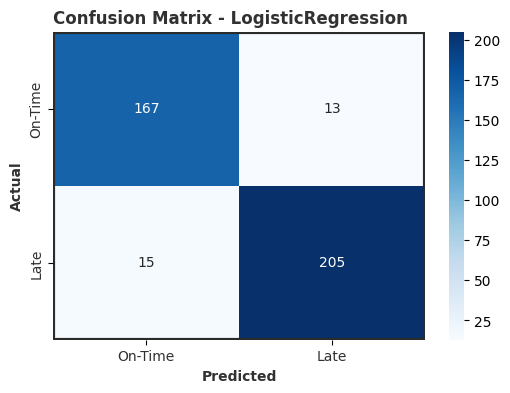

In [77]:
from sklearn.metrics import confusion_matrix

# best y predict is logistic
y_predict_best = y_predict_logistic

Conf_matrix = confusion_matrix(y_test_class, y_predict_best)

plt.figure(figsize=(6, 4))

sns.heatmap(
    Conf_matrix,
    annot=True, # numebr each cell
    fmt="d", # format int
    cmap="Blues", # color
    xticklabels=["On-Time", "Late"], # Model Prediction
    yticklabels=["On-Time", "Late"], # Model Actual
)

# The frame around the plot
rect = patches.Rectangle(
    (0, 0), 2, 2, 
    linewidth=3, 
    edgecolor='#2b2b2b', 
    facecolor='none')
plt.gca().add_patch(rect)
 # labels
plt.xlabel("Predicted", color="#313131", fontweight="bold")
plt.ylabel("Actual", color="#313131", fontweight="bold")

plt.title(f"Confusion Matrix - {best_model_name}",
          color="#313131",
          fontweight="bold",
          loc="left")

plt.xticks(color="#313131")
plt.yticks(color="#313131")

plt.show()


- **Bottom Left (FN):** 15 orders were late, but the model did not predict them as late.
- **Top Right (FP):** 13 orders were not late, but the model predicted they would be late.
- **Top Left (TN):** 167 orders arrive on time, and the model correctly predicted them.
- **Bottom Right (TP):** 167 orders arrive late, and the model correctly predicted them.

The model examined 400 orders and incorrectly predicted 28 of them, which


### **Precision and Recall**
These two metrics measure the "quality" of your model's predictions for the positive class (in this case: Late).

#### 1. Precision
This metric answers the question: When the model says "the order will be late," how reliable is it?

$$Precision = \frac{TP}{TP + FP}$$

*   **Numerator:** The number of cases correctly identified as late (TP).
*   **Denominator:** All cases the model predicted as "late" (both correct and incorrect).

**Interpretation:** If Precision is high (close to 1), it means the model has few "false alarms" (FP). In other words, whenever it says "late," it is likely actually late.

#### 2. Recall (Sensitivity)
This metric answers the question: What percentage of all orders that were actually late was the model able to identify?

$$Recall = \frac{TP}{TP + FN}$$

*   **Numerator:** The number of cases correctly identified as late (TP).
*   **Denominator:** All cases that were "late" in reality (including TPs and those the model missed, i.e., FNs).

In [78]:
from sklearn.metrics import precision_score, recall_score

# best y predict is logistic
# y_predict_best = y_predict_logistic

precision = precision_score(y_test_class, y_predict_best)
recall = recall_score(y_test_class, y_predict_best)

print(f"Precision of {best_model_name}: {precision:.4f}")
print(f"Recall of {best_model_name}: {recall:.4f}")


Precision of LogisticRegression: 0.9404
Recall of LogisticRegression: 0.9318


These two metrics are interpreted for the positive class (usually **Late**).

#### Precision = 0.9404
This means that out of all the orders the model predicted would be late, approximately **94.04%** actually were late.

**Formula:**
$$Precision = \frac{TP}{TP + FP}$$

**Matrix:**
$$Precision = \frac{205}{205 + 13} = 0.9404$$

**Interpretation:** When the model issues a "late" warning, it is correct in most cases.

#### Recall = 0.9318
This means that out of all the orders that were actually late, the model correctly identified approximately **93.18%** of them.

**Formula:**
$$Recall = \frac{TP}{TP + FN}$$

**Matrix:**
$$Recall = \frac{205}{205 + 15} = 0.9318$$

**Interpretation:** The model was able to capture most of the actual late orders.

---

### Short Business Interpretation
*   **High Precision:** The model's late-delivery warnings are reliable.
*   **High Recall:** The model does not miss most actual late deliveries.
*   Since **FN** is more critical in delivery services, the **Recall** value is more important.

**Conclusion:**
The **LogisticRegression** model performs well because both Precision and Recall are high. Specifically, a Recall of **0.9318** shows that it only missed about **6.82%** of actual late deliveries.

### Part 3: Model Interpretation and Feature Importance

To better understand the problem, we must identify which factors contribute most to increasing delivery time.

#### 1. Extracting Coefficients

- Extract the coefficients (`coef_`) from the linear regression model (built in Step 2).
- Since you used `OneHotEncoder`, the column names have changed. Use the `.get_feature_names_out()` method on the `preprocessor` section to retrieve the new feature names.
- Plot a **Bar Plot** of the top 5 features with the highest coefficients.
- Which factor adds the most time to delivery? (For example: heavy traffic or snowy weather?)

In [133]:
# model = model_logistic_regression

#---------------------------------
# 1st part: feature_names= name of columns num and cat
feature_names = model_logistic_regression.named_steps['preprocessor'].get_feature_names_out()

# 2nd part: coefficients= value of each columns
coefficients = model_logistic_regression.named_steps['classifier'].coef_

In [134]:
feature_names

array(['num__Distance_km', 'num__Prep_Time_min',
       'num__Courier_Experience_yrs', 'cat__Weather_Foggy',
       'cat__Weather_Rainy', 'cat__Weather_Snowy', 'cat__Weather_Sunny',
       'cat__Traffic_Level_High', 'cat__Traffic_Level_Jam',
       'cat__Traffic_Level_Low', 'cat__Traffic_Level_Medium',
       'cat__Vehicle_Type_Bicycle', 'cat__Vehicle_Type_Car',
       'cat__Vehicle_Type_Scooter'], dtype=object)

In [135]:
coefficients

array([[ 2.09188454,  1.75372375, -0.26679   ,  0.02155887,  0.36069659,
         1.78966284, -2.16066469,  1.03036937,  4.01645532, -3.50678974,
        -1.52878133,  3.6987114 , -2.5162388 , -1.17121899]])

Create one dataframe

In [136]:
df_coefficients = (pd.DataFrame({
    "features": feature_names,
    "coefficients": coefficients[0]})
    .sort_values(by="coefficients", ascending=False))

df_coefficients["features"] = (df_coefficients["features"]
                               .str.replace("cat__", "")
                               .str.replace("num__", ""))

df_coefficients


,features,coefficients
8,Traffic_Level_Jam,4.016455
11,Vehicle_Type_Bicycle,3.698711
0,Distance_km,2.091885
5,Weather_Snowy,1.789663
1,Prep_Time_min,1.753724
7,Traffic_Level_High,1.030369
4,Weather_Rainy,0.360697
3,Weather_Foggy,0.021559
2,Courier_Experience_yrs,-0.266790
13,Vehicle_Type_Scooter,-1.171219


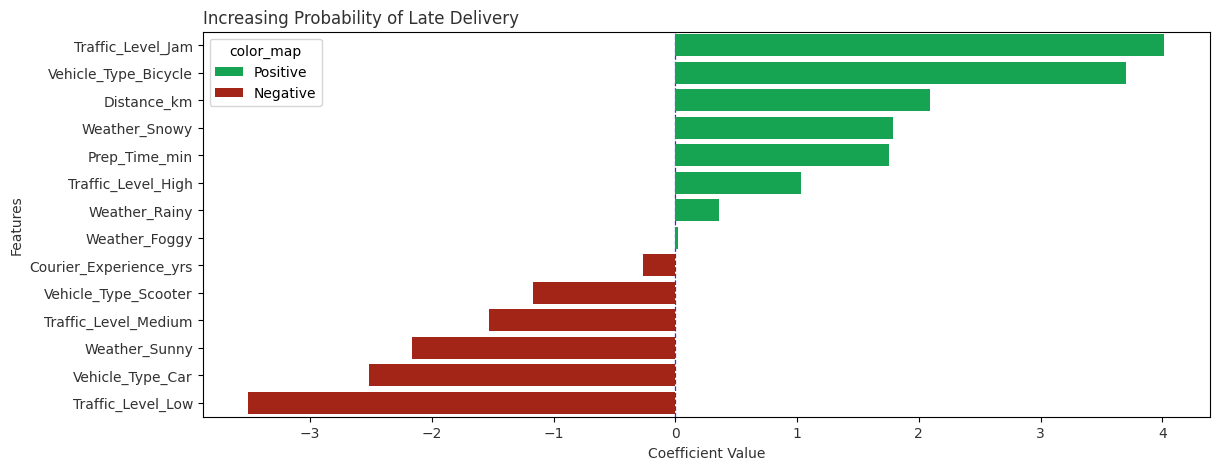

In [137]:
plt.figure(figsize=(13,5))


df_coefficients['color_map'] = df_coefficients['coefficients'].apply(lambda x: 'Positive' if x > 0 else 'Negative')


sns.barplot(
    data = df_coefficients,
    x="coefficients",
    y="features",
    hue="color_map",
    palette={'Positive': "#00BB4E", 'Negative': "#b91300"},
    zorder = 2
)

plt.axvline(0, color="#2C29FC", linewidth=0.9, linestyle='--', zorder = 1)


plt.title("Increasing Probability of Late Delivery", color="#313131", loc = "left")
plt.xticks(color="#313131")
plt.yticks(color="#313131")

plt.xlabel("Coefficient Value", color="#313131")
plt.ylabel("Features", color="#313131")

plt.show()

Top Positive

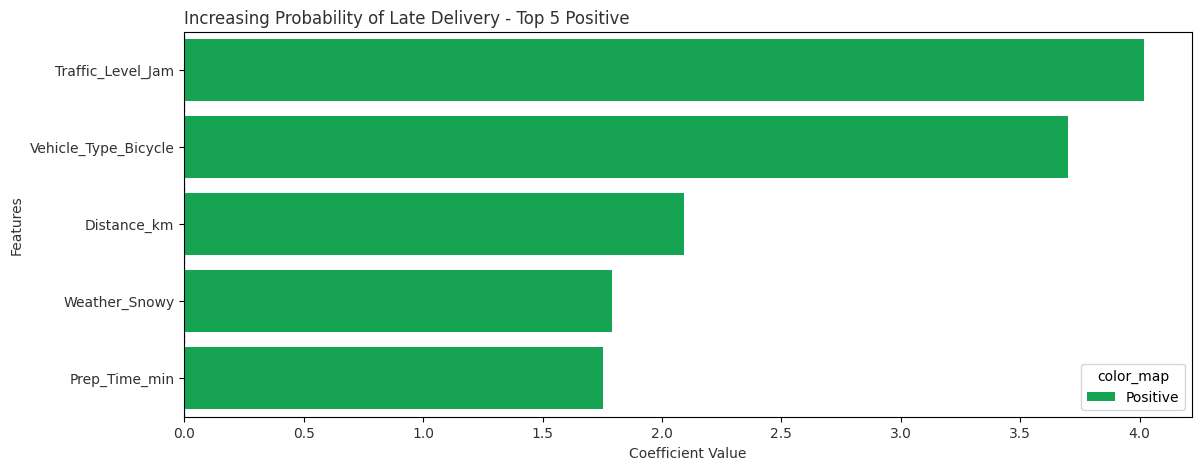

In [149]:
plt.figure(figsize=(13,5))

df_coefficients['color_map'] = df_coefficients['coefficients'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

sns.barplot(
    data=df_coefficients.head(5),
    x="coefficients",
    y="features",
    hue="color_map",
    palette={'Positive': "#00BB4E", 'Negative': "#b91300"},
    zorder = 2
)

plt.axvline(0, color="#2C29FC", linewidth=0.9, linestyle='--', zorder = 1)

plt.title("Increasing Probability of Late Delivery - Top 5 Positive", color="#313131", loc = "left")
plt.xticks(color="#313131")
plt.yticks(color="#313131")

plt.xlabel("Coefficient Value", color="#313131")
plt.ylabel("Features", color="#313131")

plt.show()

Top Absolute

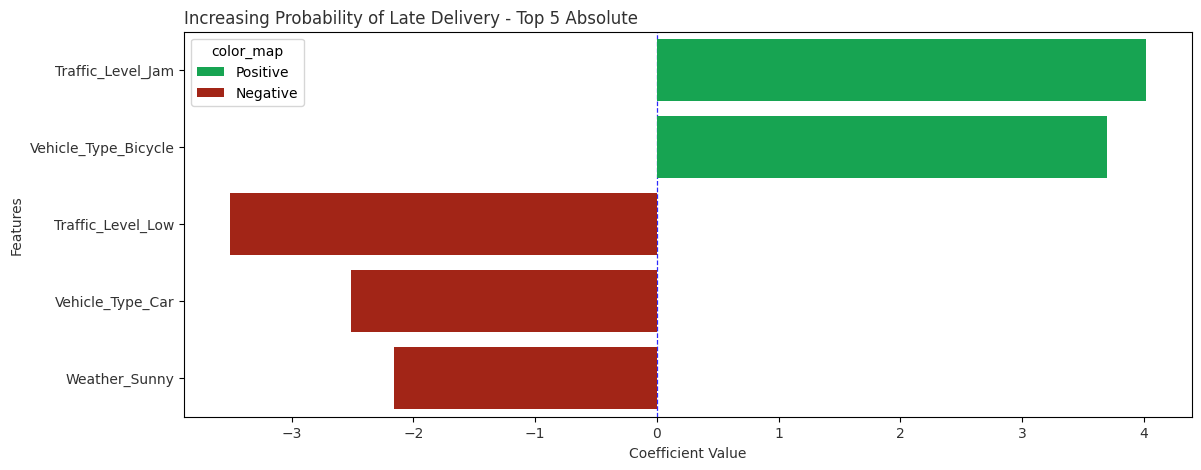

In [155]:
df_coefficients_absolute = df_coefficients.copy()
df_coefficients_absolute["Absolute"] = df_coefficients_absolute["coefficients"].abs()
df_coefficients_absolute = df_coefficients_absolute.sort_values(by="Absolute", ascending=False)

plt.figure(figsize=(13,5))

df_coefficients_absolute['color_map'] = df_coefficients_absolute['coefficients'].apply(lambda x: 'Positive' if x > 0 else 'Negative')

sns.barplot(
    data = df_coefficients_absolute.head(5),
    x="coefficients",
    y="features",
    hue="color_map",
    palette={'Positive': "#00BB4E", 'Negative': "#b91300"},
    zorder = 2
)

plt.axvline(0, color="#2C29FC", linewidth=0.9, linestyle='--', zorder = 1)

plt.title("Increasing Probability of Late Delivery - Top 5 Absolute", color="#313131", loc = "left")
plt.xticks(color="#313131")
plt.yticks(color="#313131")

plt.xlabel("Coefficient Value", color="#313131")
plt.ylabel("Features", color="#313131")

plt.show()

In [ ]:
df_coefficients = (df_coefficients["coefficients"]
                               .abs()
                               .sort_values(by="absolute", ascending=False))
df_coefficients

TypeError: Series.sort_values() got an unexpected keyword argument 'by'